### Data Analysis Project - Titanic
### Objective: Explore dataset, find insights, build simple model

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

### Load Dataset

In [2]:
df = pd.read_csv("../data/titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(df.shape)

(891, 12)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [5]:
df.describe(include = "all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [6]:
(df.isnull().sum()/len(df))*100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

In [7]:
print(df.duplicated().sum())

0


### Cleaning Plan

- **Columns to drop**
  - PassengerId → irrelevant unique identifier, no predictive value.
  - Name → too granular, not useful for modeling.
  - Ticket → messy string, not standardized.
  - Cabin → mostly missing, unreliable.

- **Handling missing values**
  - Age → impute with median (robust to outliers).
  - Embarked → impute with mode (most common port).
  - Cabin → drop column entirely (too sparse).

- **Type conversions**
  - Sex → convert to categorical (male/female).
  - Embarked → convert to categorical (C/Q/S).
  - Survived → keep as integer (target variable).


### Example: drop PassengerId

In [8]:
df.drop(columns=["PassengerId"], inplace=True)

### Convert categorical to category type

In [9]:
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

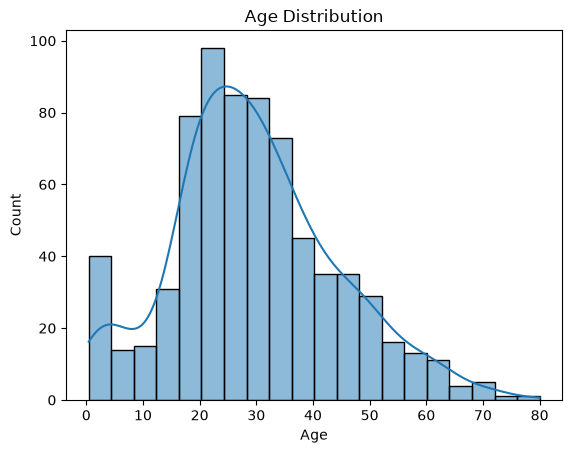

In [10]:
sns.histplot(df["Age"], kde=True)
plt.title("Age Distribution")
plt.show()

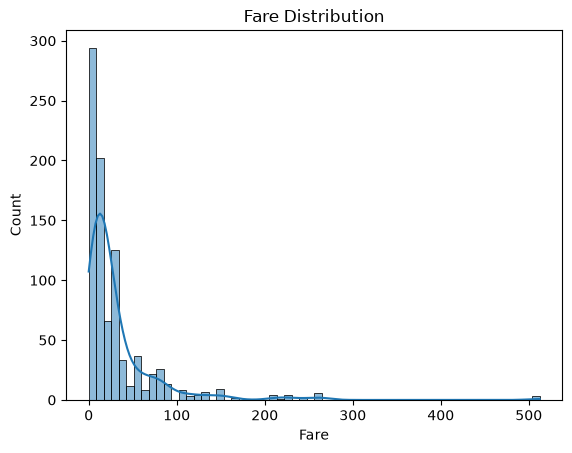

In [11]:
sns.histplot(df["Fare"], kde=True)
plt.title("Fare Distribution")
plt.show()

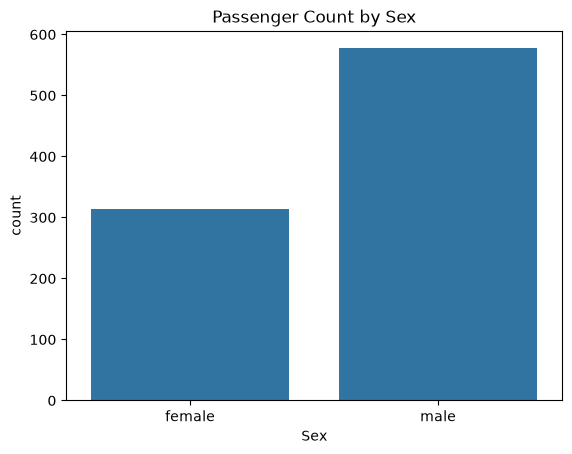

In [12]:
sns.countplot(x="Sex", data=df)
plt.title("Passenger Count by Sex")
plt.show()

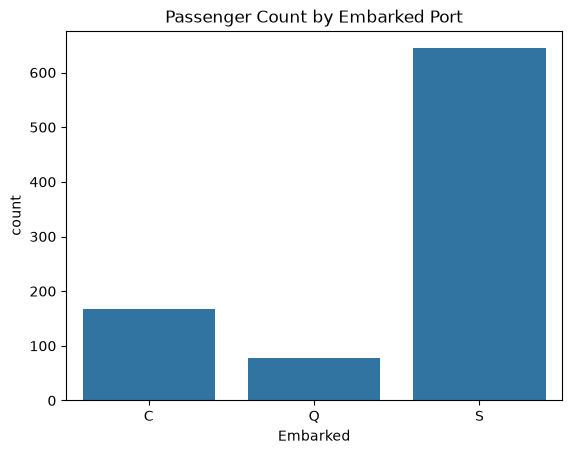

In [13]:
sns.countplot(x="Embarked", data=df)
plt.title("Passenger Count by Embarked Port")
plt.show()

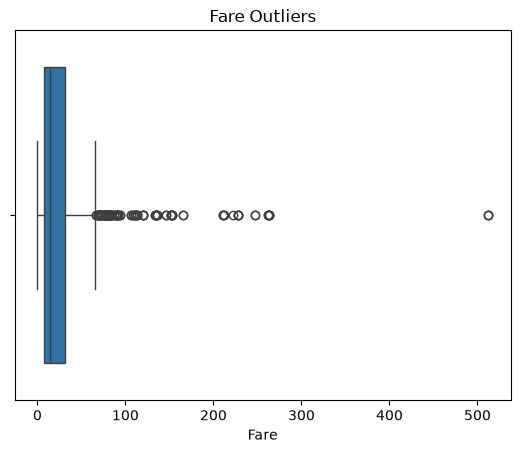

In [14]:
sns.boxplot(data=df, x="Fare")
plt.title("Fare Outliers")
plt.show()


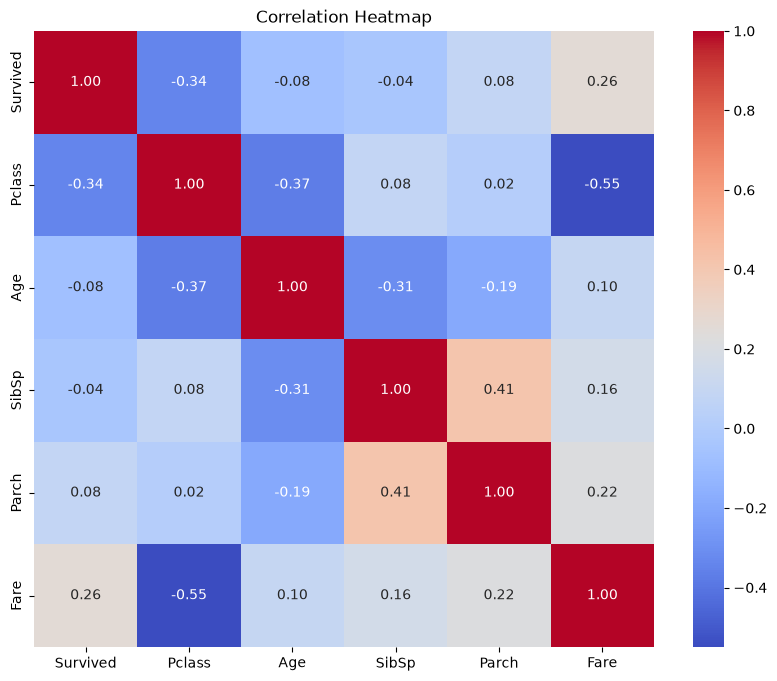

In [15]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Check missing values again:

In [16]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

Handle Age (numeric, missing) → impute with median:

In [17]:
df["Age"] = df.groupby("Pclass")["Age"].transform(
    lambda x: x.fillna(x.median())
)

Handle Embarked (categorical, missing) → impute with mode:

In [18]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

Handle Cabin (mostly missing) → drop column:

In [19]:
df.drop(columns=["Cabin"], inplace=True)

Verify Cleaning

In [20]:
df.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64

Encode categorical variables

In [21]:
# Convert Sex to numeric
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# One-hot encode Embarked
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True,
    dtype = int
    )

Create new features

In [22]:
# Family size = SibSp + Parch + 1 (self)
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# IsAlone = 1 if FamilySize == 1 else 0
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

In [23]:
# df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)

Verify

In [24]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S,FamilySize,IsAlone
0,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,0,1,2,0
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,0,0,2,0
2,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,0,1,1,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,0,1,2,0
4,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,0,1,1,1


In [25]:
df.drop(columns=["Name", "Ticket"], inplace=True)

In [26]:
print(df.dtypes)          # should show int64/float64 only

Survived         int64
Pclass           int64
Sex           category
Age            float64
SibSp            int64
Parch            int64
Fare           float64
Embarked_Q       int64
Embarked_S       int64
FamilySize       int64
IsAlone          int64
dtype: object


In [27]:
print(df.isnull().sum())  # should all be zero

Survived      0
Pclass        0
Sex           0
Age           0
SibSp         0
Parch         0
Fare          0
Embarked_Q    0
Embarked_S    0
FamilySize    0
IsAlone       0
dtype: int64


In [28]:
df.to_csv("../data/titanic_clean.csv", index=False)